# Full results

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re
import statsmodels.api as sm
from statsmodels.formula.api import ols

sns.set_theme(style="darkgrid", font="DejaVu Serif") #TODO: fix with actual thesis font

matrix_path = "/home/mengelsl/MA-bench-framework/matrices/spmv"

def get_mb(n, randomness):
    r_str = str(randomness).replace('.', '-')
    f_path = os.path.join(matrix_path, f"{r_str}_N{int(n)}.bin")
    try:
        return round(os.path.getsize(f_path) / (1024**2))
    except: return None

native_folder = {
    "/home/mengelsl/MA-bench-framework/outputs/spmv/v3/native/",
    "/home/mengelsl/MA-bench-framework/outputs/spmv/v3/native2/",
    "/home/mengelsl/MA-bench-framework/outputs/spmv/v3/native3/",
    "/home/mengelsl/MA-bench-framework/outputs/spmv/v3/native4/",
    "/home/mengelsl/MA-bench-framework/outputs/spmv/v3/native5/"
}

sme_folder = {
    "/home/mengelsl/MA-bench-framework/outputs/spmv/v3/sme/",
    "/home/mengelsl/MA-bench-framework/outputs/spmv/v3/sme3/",
}

sev_folder = {
    "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sev/",
}

native_interleave_folder = {
    "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/native_interleave/",
}

sme_interleave_folder = {
    "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sme_interleave/",
}

sev_interleave_folder = {
    "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sev_interleave/",
}


In [14]:
main_folder = {
    "Native_strict": native_folder,
    "Native_interleave": native_interleave_folder,
    "SME_strict": sme_folder,
    "SME_interleave": sme_interleave_folder,
    "SME+SEV_strict": sev_folder,
    "SME+SEV_interleave": sev_interleave_folder,
}

results_list = []

for label, folder_set in main_folder.items():
    for idx, path in enumerate(folder_set):
        f_path = os.path.join(path, "results.csv")
        print(f"Checking for {label} at {f_path}...")
        if os.path.exists(f_path):
            df = pd.read_csv(f_path)
            df["Mode"] = label.split("_interleave")[0].split("_strict")[0]
            df["VM_NUMA"] = "interleave" if "interleave" in label else "strict"
            df["ID"] = idx
            results_list.append(df)

df_raw = pd.concat(results_list, ignore_index=True)
df_raw.rename(columns={"Process_NUMA_Policy": "Process_NUMA"}, inplace=True)

print(f"Loaded {len(df_raw)} raw rows.")

Checking for Native_strict at /home/mengelsl/MA-bench-framework/outputs/spmv/v3/native4/results.csv...
Checking for Native_strict at /home/mengelsl/MA-bench-framework/outputs/spmv/v3/native3/results.csv...
Checking for Native_strict at /home/mengelsl/MA-bench-framework/outputs/spmv/v3/native/results.csv...
Checking for Native_strict at /home/mengelsl/MA-bench-framework/outputs/spmv/v3/native5/results.csv...
Checking for Native_strict at /home/mengelsl/MA-bench-framework/outputs/spmv/v3/native2/results.csv...
Checking for Native_interleave at /home/mengelsl/MA-bench-framework/outputs/SpMV_final/native_interleave/results.csv...
Checking for SME_strict at /home/mengelsl/MA-bench-framework/outputs/spmv/v3/sme/results.csv...
Checking for SME_strict at /home/mengelsl/MA-bench-framework/outputs/spmv/v3/sme3/results.csv...
Checking for SME_interleave at /home/mengelsl/MA-bench-framework/outputs/SpMV_final/sme_interleave/results.csv...
Checking for SME+SEV_strict at /home/mengelsl/MA-bench-fram

In [21]:
# Iterations is in here, because it does not change per config and this simply keeps the column
config_cols_raw = ["Mode", "ID", "Matrix", "Cores", "Process_NUMA", "VM_NUMA", "Iterations"]
metric_cols_raw = [ "IO_Time", "SpMV_Time", "Perf_Cycles", "Perf_Instructions", "Perf_CacheMisses", "Perf_dTLBMisses" ]

config_drop_counts = []

def iqr_mark_outliers(group):
    group = group.copy()
    group_drops = 0

    for col in metric_cols_raw:
        if col not in group.columns:
            continue
        
        data = pd.to_numeric(group[col], errors="coerce")
        valid = data.dropna()
        
        if valid.empty:
            continue
        
        q1, q3 = valid.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        
        mask = (data >= lower) & (data <= upper)
        
        group_drops += (~mask & data.notna()).sum()
        
        # Mark outliers as NaN
        group.loc[~mask, col] = np.nan

    config_drop_counts.append(group_drops)
    return group

df_clean = df_raw.groupby(config_cols_raw).apply(iqr_mark_outliers, include_groups=False).reset_index()

total_points_removed = np.sum(config_drop_counts)

print(f"Total metric data points: {len(df_raw) * len(metric_cols_raw)}")
print(f"Total data points removed: {total_points_removed}")
print(f"Data points removed (%): {total_points_removed / (len(df_raw) * len(metric_cols_raw)) * 100:.2f}%")

Total metric data points: 79200
Total data points removed: 3916
Data points removed (%): 4.94%


<Figure size 1600x400 with 0 Axes>

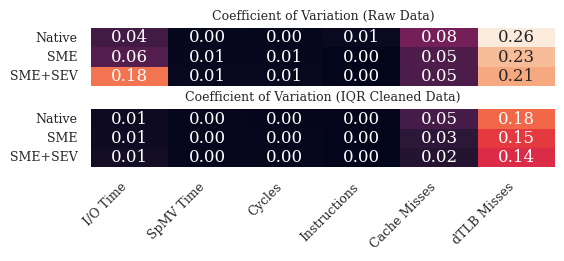

In [22]:
def compute_cv_per_mode(df, config_cols_raw, metrics):
    stats = (
        df
        .groupby(config_cols_raw)[metrics]
        .agg(["mean", "std"])
    )
    
    cv = stats.xs("std", level=1, axis=1) / stats.xs("mean", level=1, axis=1)

    # Aggregate over Mode (first level)
    cv_mode = cv.groupby(level=0).mean()

    cv_mode.fillna(0, inplace=True)
    
    return cv_mode

cv_raw_mode = compute_cv_per_mode(df_raw, config_cols_raw, metric_cols_raw)
cv_clean_mode = compute_cv_per_mode(df_clean, config_cols_raw, metric_cols_raw)

rename_dict = {
	"IO_Time": "I/O Time",
	"SpMV_Time": "SpMV Time",
	"Perf_Cycles": "Cycles",
    "Perf_Instructions": "Instructions",
    "Perf_CacheMisses": "Cache Misses",
    "Perf_dTLBMisses": "dTLB Misses",
}

plt.figure(figsize=(16, 4))
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True , gridspec_kw={'right': 0.85})


v_max = max(cv_raw_mode.max().max(), cv_clean_mode.max().max())

kwargs = dict(
    annot=True,
    fmt=".2f",
    cbar=False,
    vmin=0,
    vmax=v_max,
)


sns.heatmap(cv_raw_mode.rename(columns=rename_dict), ax=ax1, **kwargs)
ax1.set_title("Coefficient of Variation (Raw Data)", fontsize=9)
ax1.set_ylabel("")
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=9)

sns.heatmap(cv_clean_mode.rename(columns=rename_dict), ax=ax2, **kwargs)
ax2.set_title("Coefficient of Variation (IQR Cleaned Data)", fontsize=9)
ax2.set_ylabel("")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax2.set_yticklabels(ax2.get_yticklabels(), fontsize=9)

plt.subplots_adjust(hspace=0.4, top=0.4)
plt.savefig("images/cv_heatmap_raw_vs_clean.pdf", bbox_inches='tight')

In [23]:
# fully cleaned data grouped by config, median of runs
df = df_clean.groupby(config_cols_raw)[metric_cols_raw].median().reset_index()

df['N'] = df['Matrix'].str.extract(r'N(\d+)').astype(int)
r = df['Matrix'].str.extract(r'(\d)-(\d)')
df['Randomness'] = (r[0] + "." + r[1]).astype(float)
df['MB'] = df.apply(lambda row: get_mb(row['N'], row['Randomness']), axis=1).astype('Int64')
k = 30  # nnz per row
#2 operations per non-zero element (multiply and add)
# TODO: the cpp gflops were calculated wrong, delete everything regarding that
df['SpMV_GFLOPS'] = ( 2 * k * df['N']) / ( (df['SpMV_Time'] / df['Iterations']) * 1e9)
#based on 32MB L3 per 8 cores
L3_size = {
    1: 32,
    8: 32,
    24: 96,
    48: 192,
}
df['L3_fit'] = df['MB'] <= df['Cores'].map(L3_size)
df["Perf_IPC"] = df['Perf_Instructions'] / df['Perf_Cycles']
df.drop(columns=["N","Matrix"], inplace=True)

config_cols = ["Mode", "MB", "Randomness", "Cores", "Process_NUMA", "VM_NUMA", "L3_fit"]
metric_cols = metric_cols_raw + ["SpMV_GFLOPS", "Perf_IPC"]

df.head()

,Mode,ID,Cores,Process_NUMA,VM_NUMA,Iterations,IO_Time,SpMV_Time,Perf_Cycles,Perf_Instructions,Perf_CacheMisses,Perf_dTLBMisses,Randomness,MB,SpMV_GFLOPS,L3_fit,Perf_IPC
0,Native,0,1,interleave,interleave,369,0.081600,9.948239,3.613565e+10,1.993093e+11,3298979.0,364995.0,0.0,500,3.205531,False,5.515586
1,Native,0,1,interleave,strict,369,0.082036,9.993071,3.630054e+10,1.993093e+11,3276049.0,395074.5,0.0,500,3.191150,False,5.490532
2,Native,0,1,membind,interleave,369,0.081796,9.945920,3.612669e+10,1.993093e+11,3276159.0,345223.0,0.0,500,3.206279,False,5.516955
3,Native,0,1,membind,strict,369,0.081642,9.991050,3.630536e+10,1.993093e+11,3250803.0,344848.0,0.0,500,3.191796,False,5.489804
4,Native,0,8,interleave,interleave,713,0.081595,10.267954,2.962630e+11,3.852660e+11,16812143.0,16328.0,0.0,500,6.001026,False,1.300419


In [ ]:
from itertools import product

# Use the run-level dataframe already in memory
base_df = source_df.copy()

# IDs available per (Mode, VM_NUMA)
id_choices = (
	base_df.groupby(["Mode", "VM_NUMA"])["ID"]
	.unique()
	.apply(lambda x: sorted(pd.unique(x).tolist()))
	.to_dict()
)

# Deterministic order of dimensions for combo generation
combo_keys = [
	("Native", "interleave"),
	("Native", "strict"),
	("SME", "interleave"),
	("SME", "strict"),
	("SME+SEV", "interleave"),
	("SME+SEV", "strict"),
]

# Keep only keys that actually exist in the data
combo_keys = [k for k in combo_keys if k in id_choices]

combo_frames = []
combo_specs = []

for i, id_tuple in enumerate(product(*[id_choices[k] for k in combo_keys]), start=1):
	spec = dict(zip(combo_keys, id_tuple))
	combo_name = f"combo{i}"

	parts = []
	for (mode, vm), run_id in spec.items():
		part = base_df[
			(base_df["Mode"] == mode) &
			(base_df["VM_NUMA"] == vm) &
			(base_df["ID"] == run_id)
		]
		parts.append(part)

	combo_df = pd.concat(parts, ignore_index=True)
	combo_df["Combo"] = combo_name
	combo_frames.append(combo_df)

	row = {"Combo": combo_name}
	row.update({f"{m}_{v}_ID": rid for (m, v), rid in spec.items()})
	combo_specs.append(row)

all_combos_df = pd.concat(combo_frames, ignore_index=True)
all_combos_specs_df = pd.DataFrame(combo_specs)

print(f"Created all_combos_df with {len(all_combos_df)} rows across {all_combos_df['Combo'].nunique()} combos")
display(all_combos_specs_df)


Generated 10 overhead dataframes


,Combo,Rows,Native_IDs
0,combo1,320,[0]
1,combo10,320,"[0, 4]"
2,combo2,320,[0]
3,combo3,320,"[0, 1]"
4,combo4,320,"[0, 1]"
5,combo5,320,"[0, 2]"
6,combo6,320,"[0, 2]"
7,combo7,320,"[0, 3]"
8,combo8,320,"[0, 3]"
9,combo9,320,"[0, 4]"


Dimensions to visualize per Metric
Mode - 2 values
Matrix MB - 5 values
Matrix Randomness - 2 values
Cores - 4 values
VM NUMA Policy - 2 values
Process NUMA Policy - 2 values
= 6 Dimensions with 320 configs (cut down from 480 configs with the overhead_df)

How to visualize that?

In [26]:
overhead_df.groupby("Mode")["SpMV_GFLOPS_pct"].aggregate(['mean', 'median'])

,mean,median
Mode,,
SME,-1.802786,-0.537495
SME+SEV,-2.747194,-0.688829


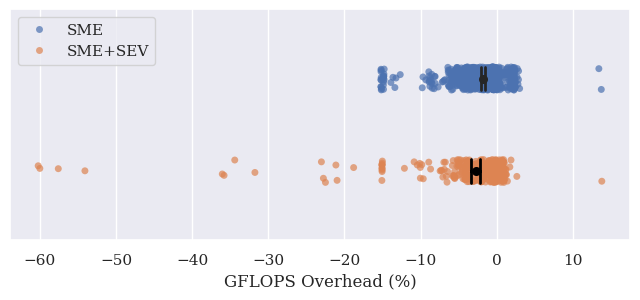

In [27]:
DODGE_VAL = 0.4 

plt.figure(figsize=(8, 3))
sns.pointplot(
    data=overhead_df, 
    x="SpMV_GFLOPS_pct", 
    hue="Mode", 
    dodge=DODGE_VAL, 
    linestyle=None,
    markersize=5,        
    linewidth=2,             
    capsize=0.1,
    palette="dark:black",
	legend=False,
	zorder=2
)

ax = sns.stripplot(
    data=overhead_df, 
    x="SpMV_GFLOPS_pct", 
    hue="Mode", 
    dodge=DODGE_VAL,   
    alpha=0.7,
	zorder=1
)

plt.legend(title=None, loc='upper left')
plt.xlabel("GFLOPS Overhead (%)")
plt.ylabel("")
plt.savefig("images/GFLOPS_Overhead_Distribution.pdf", bbox_inches='tight')

In [108]:
count = (overhead_df["SpMV_GFLOPS_pct"] > 1).sum()
total = overhead_df["SpMV_GFLOPS_pct"].count()
count2 = (overhead_df["SpMV_GFLOPS_pct"] > 0).sum()
total2 = overhead_df["SpMV_GFLOPS_pct"].count()

print(f"Encrypted outperforms native by > 1%: {count} / {total} = {count / total}")
print(f"Encrypted outperforms native by > 0%: {count2} / {total2} = {count2 / total2}")

Encrypted outperforms native by > 1%: 22 / 320 = 0.06875
Encrypted outperforms native by > 0%: 67 / 320 = 0.209375


In [109]:
count_SME_low_impact = ((overhead_df["Mode"] == "SME") & (overhead_df["SpMV_GFLOPS_pct"] > -1)).sum()
total_SME = (overhead_df["Mode"] == "SME").sum()
count_SEV_low_impact = ((overhead_df["Mode"] == "SME+SEV") & (overhead_df["SpMV_GFLOPS_pct"] > -1)).sum()
total_SEV = (overhead_df["Mode"] == "SME+SEV").sum()
print(f"SME low impact (> -1%): {count_SME_low_impact} / {total_SME} = {count_SME_low_impact / total_SME}")
print(f"SME+SEV low impact (> -1%): {count_SEV_low_impact} / {total_SEV} = {count_SEV_low_impact / total_SEV}")

SME low impact (> -1%): 104 / 160 = 0.65
SME+SEV low impact (> -1%): 77 / 160 = 0.48125


In [29]:
def plot_metric_by_dimensions(input_df, metric, y_axis_name, top, figname=None, palette=None, legend=True):
    all_dims = ['MB', 'Randomness', 'Cores', 'VM_NUMA', 'Process_NUMA']

    dim_orders = {
        "VM_NUMA": ["strict", "interleave"],
        "Process_NUMA": ["membind", "interleave"],
    }

    fig, axes = plt.subplots(nrows=1, ncols=len(all_dims), figsize=(8, 3), constrained_layout=True, sharey=True)

    fig.supylabel(f"{y_axis_name}", fontsize=10)
    for ax, a in zip(axes, all_dims):
        sns.barplot(
            data=input_df,
            x=a,
            y=metric,
            hue='Mode',
            order=dim_orders.get(a, None),
            errorbar=('ci', 95),
            edgecolor='black',
            ax=ax,
            palette=palette
        )

        if a == "MB":
            ax.set_title("Matrix Size (MB)", y=1.2, fontsize=9)
        else:
            ax.set_title(a.replace("_", " "), y=1.2, fontsize=10)

        ax.set_ylabel("")
        ax.set_xlabel("")
        rotation = 0 if a in ['VM_NUMA', 'Process_NUMA'] else 45
        ax.tick_params(axis='x', rotation=rotation, labelsize=8)

        if top:
            ax.xaxis.set_ticks_position('top')
            ax.xaxis.set_label_position('top')
        else:
            ax.xaxis.set_ticks_position('bottom')
            ax.xaxis.set_label_position('bottom')

        ax.tick_params(axis='y', labelsize=8)
        ax.get_legend().remove()

    handles, labels = axes[0].get_legend_handles_labels()
    if legend:
        fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.1), fontsize=8)

→ MB:
Mode  Native
MB          
10      40.0
70      42.8
150     36.9
500     14.6
3000     7.9
------------------------------------------------------------
→ Randomness:
Mode        Native
Randomness        
0.0           34.6
1.0           22.2
------------------------------------------------------------
→ Cores:
Mode   Native
Cores        
1         2.4
8        10.0
24       34.9
48       66.3
------------------------------------------------------------
→ VM NUMA:
Mode        Native
VM_NUMA           
strict        27.2
interleave    29.7
------------------------------------------------------------
→ Process NUMA:
Mode          Native
Process_NUMA        
membind         28.4
interleave      28.4
------------------------------------------------------------


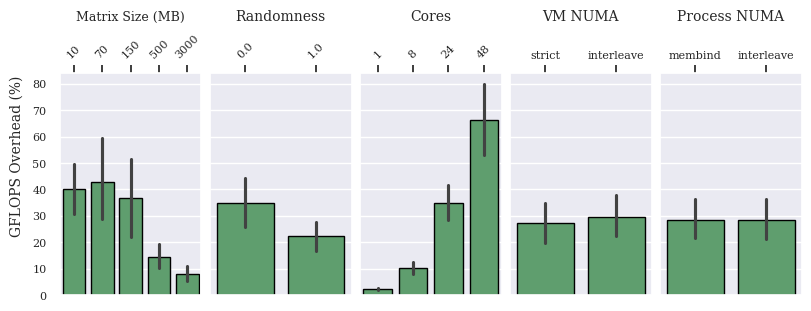

In [111]:
base = sns.color_palette("deep", 3)
palette = {
    "Native": base[2],  
    "SME": base[0],     
    "SME+SEV": base[1] 
}
plot_metric_by_dimensions(df[df["Mode"] == "Native"], "SpMV_GFLOPS", "GFLOPS Overhead (%)", top=True, figname="absolute_gflops_per_dim.pdf", palette=palette, legend=False)

In [112]:
# Mean process-NUMA difference in Native SpMV GFLOPS (percent)
pair_cols = ["MB", "Randomness", "Cores", "VM_NUMA"]

# Use existing proc_order if available, otherwise fall back
proc_candidates = globals().get("proc_order", ["membind", "interleave"])
proc_order_local = [p for p in proc_candidates if p in df["Process_NUMA"].dropna().unique()]

if len(proc_order_local) < 2:
	raise ValueError(
		f"Need two Process_NUMA values, found: {proc_order_local}"
	)

base_proc = proc_order_local[0]       # membind
compare_proc = proc_order_local[1]    # interleave

proc_diff_df = (
	df[df["Mode"] == "Native"]
	.pivot_table(
		index=pair_cols,
		columns="Process_NUMA",
		values="SpMV_GFLOPS",
		aggfunc="mean"
	)
	.dropna(subset=[base_proc, compare_proc])
	.reset_index()
)

proc_diff_df["Proc_NUMA_Diff_pct"] = (
	(proc_diff_df[compare_proc] - proc_diff_df[base_proc]) / proc_diff_df[base_proc] * 100
)
proc_diff_df["Abs_Proc_NUMA_Diff_pct"] = proc_diff_df["Proc_NUMA_Diff_pct"].abs()

mean_diff_pct = proc_diff_df["Proc_NUMA_Diff_pct"].mean()
mean_abs_diff_pct = proc_diff_df["Abs_Proc_NUMA_Diff_pct"].mean()

print(
	f"Mean process-NUMA difference ({compare_proc} vs {base_proc}): "
	f"{mean_diff_pct:.4f}%"
)
print(f"Mean absolute process-NUMA difference: {mean_abs_diff_pct:.4f}%")


Mean process-NUMA difference (interleave vs membind): -0.0714%
Mean absolute process-NUMA difference: 0.1976%


Plotted mean GFLOPS overhead (%) per VM/Process/Cores/Mode:
   VM_NUMA Process_NUMA  Cores    Mode  SpMV_GFLOPS_pct
interleave   interleave      1     SME            -2.29
interleave   interleave      1 SME+SEV            -2.70
interleave   interleave      8     SME            -0.07
interleave   interleave      8 SME+SEV            -0.42
interleave   interleave     24     SME            -0.33
interleave   interleave     24 SME+SEV            -1.65
interleave   interleave     48     SME            -0.77
interleave   interleave     48 SME+SEV            -2.16
interleave      membind      1     SME            -2.03
interleave      membind      1 SME+SEV            -2.83
interleave      membind      8     SME            -0.08
interleave      membind      8 SME+SEV            -0.45
interleave      membind     24     SME            -1.04
interleave      membind     24 SME+SEV            -2.01
interleave      membind     48     SME            -0.39
interleave      membind     48 SME+SEV      

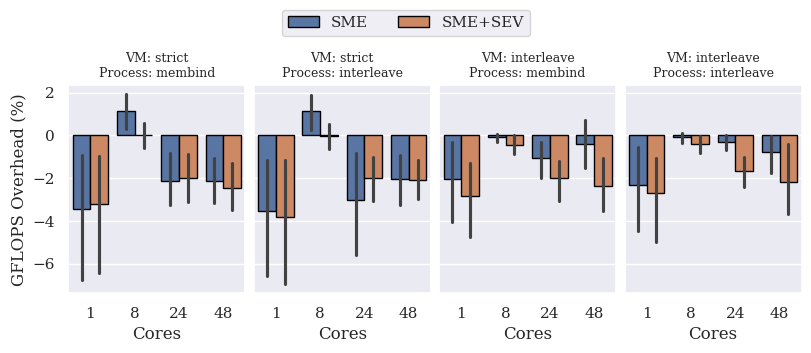

In [113]:
plot_df = overhead_df.copy()
plot_df["Cores"] = pd.to_numeric(plot_df["Cores"], errors="coerce").astype("Int64")
plot_df = plot_df.dropna(subset=["Cores", "VM_NUMA", "Process_NUMA", "Mode", "SpMV_GFLOPS_pct"]).copy()
plot_df["Cores"] = plot_df["Cores"].astype(int)

mode_order = ["SME", "SME+SEV"]
core_order = sorted(plot_df["Cores"].unique())
vm_order = [v for v in ["strict", "interleave"] if v in plot_df["VM_NUMA"].unique()]
proc_order = [p for p in ["membind", "interleave"] if p in plot_df["Process_NUMA"].unique()]
facet_order = [(vm, proc) for vm in vm_order for proc in proc_order]

palette = {
    "SME": "#4c72b0",
    "SME+SEV": "#dd8452",
}

display_values = (
    plot_df.groupby(["VM_NUMA", "Process_NUMA", "Cores", "Mode"], as_index=False)["SpMV_GFLOPS_pct"]
    .mean()
    .round(2)
    .sort_values(["VM_NUMA", "Process_NUMA", "Cores", "Mode"])
)
print("Plotted mean GFLOPS overhead (%) per VM/Process/Cores/Mode:")
print(display_values.to_string(index=False))

fig, axes = plt.subplots(
    1, len(facet_order), figsize=(8,3), sharey=True, constrained_layout=True
)
if len(facet_order) == 1:
    axes = [axes]

for ax, (vm, proc) in zip(axes, facet_order):
    sub = plot_df[(plot_df["VM_NUMA"] == vm) & (plot_df["Process_NUMA"] == proc)]
    sns.barplot(
        data=sub,
        x="Cores",
        y="SpMV_GFLOPS_pct",
        hue="Mode",
        order=core_order,
        hue_order=mode_order,
        palette=palette,
        errorbar=("ci", 95),
        edgecolor="black",
        ax=ax,
    )
    ax.set_title(f"VM: {vm}\nProcess: {proc}", fontsize=9)
    ax.set_xlabel("Cores")
    ax.set_ylabel("GFLOPS Overhead (%)" if ax is axes[0] else "")
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title=None, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.15))

fig.savefig("images/gflops_cores_numa.pdf", bbox_inches="tight")
plt.show()

In [114]:
targets = [ "SpMV_GFLOPS_pct" ]

def full_anova(df, target):
    d = df.dropna(subset=[ target, "MB", "Cores", "Randomness", "Process_NUMA", "VM_NUMA"]).copy()

	# C for categorical, handled internally by statsmodels
    formula = f"{target} ~ MB + C(Randomness) + Cores + C(Process_NUMA) + C(VM_NUMA)"

    model = ols(formula, data=d).fit()

    #https://md.psych.bio.uni-goettingen.de/mv/unit/lm_cat/lm_cat_unbal_ss_explained.html
    table = sm.stats.anova_lm(model, typ=3)

    table["eta_sq"] = table["sum_sq"] / table["sum_sq"].sum()

    return table.sort_values("eta_sq", ascending=False)

def run(df):
    df["MB"] = pd.to_numeric(df["MB"], errors="coerce").astype("float64")
    df["Cores"] = pd.to_numeric(df["Cores"], errors="coerce").astype("float64")
    df["Randomness"] = pd.to_numeric(df["Randomness"], errors="coerce").astype("float64")

    print("Rows:", len(df))

    results = {}

    for t in targets:

        anova_sme = full_anova(df[df["Mode"] == "SME"].copy(), t)
        anova_sev = full_anova(df[df["Mode"] == "SME+SEV"].copy(), t)
        results[t] = anova_sme
        results[t] = anova_sev

        print("\n" + "="*60)
        print("TARGET:", t, "MODE: SME")
        print("="*60)
        print(anova_sme)
        print("\n" + "="*60)
        print("TARGET:", t, "MODE: SME+SEV")
        print("="*60)
        print(anova_sev)

    return results


results = run(overhead_df)

Rows: 320

TARGET: SpMV_GFLOPS_pct MODE: SME
                      sum_sq     df          F    PR(>F)    eta_sq
Residual         1124.574200  154.0        NaN       NaN  0.857936
C(Randomness)      78.369709    1.0  10.732004  0.001301  0.059788
MB                 75.283489    1.0  10.309375  0.001611  0.057434
C(VM_NUMA)         30.862160    1.0   4.226286  0.041491  0.023545
Cores               0.647935    1.0   0.088729  0.766201  0.000494
Intercept           0.636223    1.0   0.087125  0.768262  0.000485
C(Process_NUMA)     0.416843    1.0   0.057083  0.811485  0.000318

TARGET: SpMV_GFLOPS_pct MODE: SME+SEV
                     sum_sq     df          F    PR(>F)    eta_sq
Residual         987.123490  154.0        NaN       NaN  0.871063
C(Randomness)     73.549301    1.0  11.474342  0.000896  0.064902
MB                60.015953    1.0   9.363020  0.002612  0.052960
Intercept         10.373544    1.0   1.618365  0.205238  0.009154
Cores              1.501463    1.0   0.234242  0.6

Analyze those configurations with high impact.

In [115]:
def top_10_percent_per_mode(df, value_col):
    return df[
        df.groupby("Mode")[value_col]
          .transform(lambda x: x.rank(method="first", ascending=True)
                               <= int(len(x) * 0.1))
    ]

cutoffs = overhead_df.groupby("Mode")["SpMV_GFLOPS_pct"].apply(
    lambda x: x.nsmallest(int(len(x) * 0.1)).max()
)

print(cutoffs)

top_configs = top_10_percent_per_mode(overhead_df, "SpMV_GFLOPS_pct")

result_df = (
    top_configs
    .melt(id_vars=["Mode"], value_vars=config_cols,
          var_name="Metric", value_name="Value")
    .groupby(["Mode", "Metric", "Value"])
    .size()
    .reset_index(name="Count")
)

result_df["Representation"] = (
    result_df.groupby(["Mode", "Metric"])["Count"]
    .transform(lambda x: 100 * x / x.sum())
)

result_df = result_df.sort_values(
    ["Mode", "Metric", "Representation"],
    ascending=[True, True, False]
)

n_levels = overhead_df[config_cols].nunique()

result_df["Expected"] = result_df["Metric"].map(lambda m: 1 / n_levels[m])

result_df["Lift"] = (
    result_df["Representation"] / 100
) / result_df["Expected"]

result_df

Mode
SME       -4.565189
SME+SEV   -4.960052
Name: SpMV_GFLOPS_pct, dtype: float64


,Mode,Metric,Value,Count,Representation,Expected,Lift
0,SME,Cores,1.0,11,68.75,0.25,2.7500
1,SME,Cores,24.0,4,25.00,0.25,1.0000
2,SME,Cores,48.0,1,6.25,0.25,0.2500
3,SME,L3_fit,False,15,93.75,0.50,1.8750
4,SME,L3_fit,1.0,1,6.25,0.50,0.1250
8,SME,MB,500.0,6,37.50,0.20,1.8750
9,SME,MB,3000.0,6,37.50,0.20,1.8750
7,SME,MB,150.0,2,12.50,0.20,0.6250
5,SME,MB,10.0,1,6.25,0.20,0.3125
6,SME,MB,70.0,1,6.25,0.20,0.3125


L3_fit  Mode   
False   SME       -1.705047
        SME+SEV   -2.192703
True    SME       -0.591436
        SME+SEV   -1.303889
Name: SpMV_GFLOPS_pct, dtype: float64


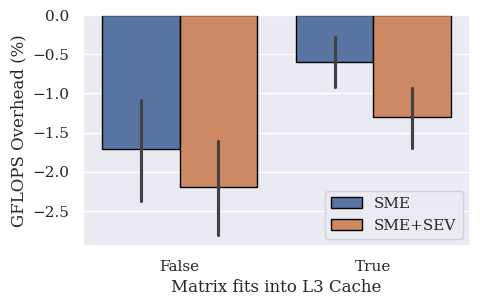

In [116]:
plt.figure(figsize=(5, 3))
sns.barplot(overhead_df, x="L3_fit", y="SpMV_GFLOPS_pct", hue="Mode", edgecolor="black")
plt.legend(title=None)
plt.xlabel("Matrix fits into L3 Cache")
plt.ylabel("GFLOPS Overhead (%)")
plt.savefig("images/overhead_by_L3_fit_SpMV_GFLOPS_pct.pdf", bbox_inches='tight')
print(overhead_df.groupby(["L3_fit", "Mode"])["SpMV_GFLOPS_pct"].mean())

                count      mean       std       sem
Mode    L3_fit                                     
SME     False      52 -2.271410  4.271943  0.592412
        True       28  0.219105  0.637223  0.120424
SME+SEV False      52 -2.155431  4.156259  0.576369
        True       28  0.128661  0.891711  0.168518


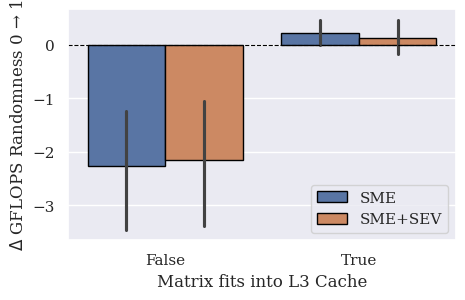

In [122]:
delta_df = (
    overhead_df
    .pivot_table(
        index=["Mode", "L3_fit", "MB", "Cores", "VM_NUMA", "Process_NUMA"],
        columns="Randomness",
        values="SpMV_GFLOPS_pct",
        aggfunc="mean"
    )
    .dropna(subset=[0.0, 1.0])
    .reset_index()
)

delta_df["Delta"] = delta_df[1.0] - delta_df[0.0]

plt.figure(figsize=(5, 3))
sns.barplot( data=delta_df, x="L3_fit", y="Delta", hue="Mode", errorbar=("ci", 95), edgecolor="black")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.legend(title=None)
plt.ylabel("$\\Delta$ GFLOPS Randomness 0 → 1")
plt.xlabel("Matrix fits into L3 Cache")
plt.savefig("images/delta_randomness_by_L3_fit_SpMV_GFLOPS_pct.pdf", bbox_inches="tight")

print(delta_df.groupby(["Mode", "L3_fit"])["Delta"].agg(["count", "mean", "std", "sem"]))

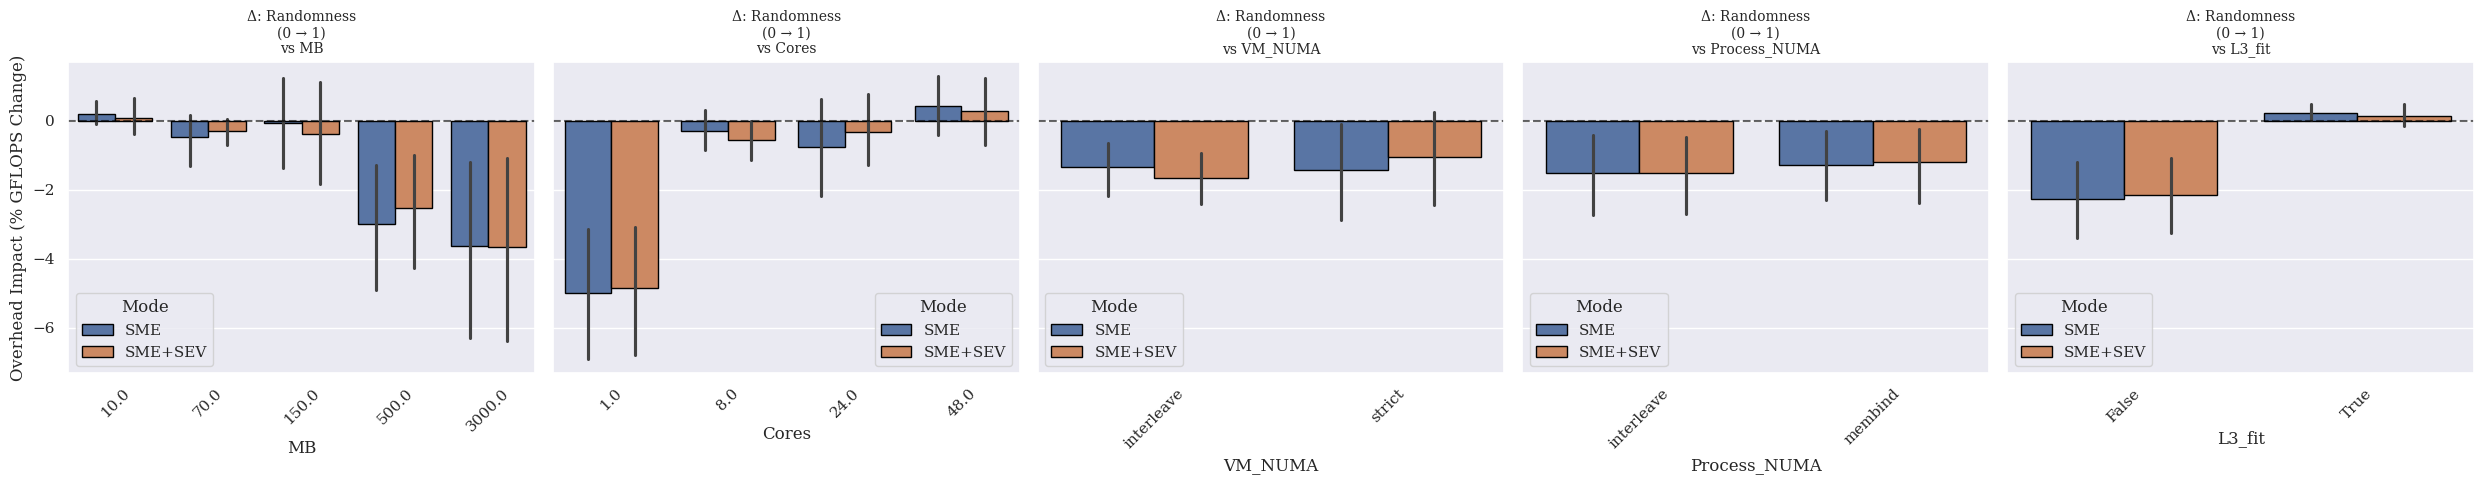

In [118]:
#matrix pattern impact
# Global configuration: (Baseline/Low State, Stressed/High State)
# Order matters: Impact = High - Low
DIM_CONFIG = {
    'Randomness': (0, 1),
    'VM_NUMA': ('strict', 'interleave'),
    'Process_NUMA': ('membind', 'interleave'),
    'L3_fit': (False, True),
}

def get_impact_df(df, target_dim):
    """
    Calculates pairwise delta for target_dim using DIM_CONFIG.
    For MB/Cores, it defaults to (min, max).
    """
    all_dims = ['Mode', 'MB', 'Cores', 'VM_NUMA', 'Process_NUMA', 'Randomness', 'L3_fit']
    index_cols = [c for c in all_dims if c != target_dim]
    
    # Get comparison values
    if target_dim in DIM_CONFIG:
        low_val, high_val = DIM_CONFIG[target_dim]
    else:
        low_val, high_val = df[target_dim].min(), df[target_dim].max()
    
    # Pivot and calculate Delta
    pivot = df.pivot_table(
        index=index_cols, 
        columns=target_dim, 
        values='SpMV_GFLOPS_pct'
    ).reset_index()
    
    # Impact = 'Stressed' minus 'Baseline'
    pivot['Impact'] = pivot[high_val] - pivot[low_val]
    
    # Store metadata for the plotter to use in titles
    pivot.attrs['comparison'] = f"{low_val} → {high_val}"
    pivot.attrs['target'] = target_dim
    return pivot

def plot_impact_comparison(impact_df, compare_features):
    """
    Plots the impact with automated, descriptive titles.
    """
    target = impact_df.attrs.get('target', 'Dimension')
    comp_str = impact_df.attrs.get('comparison', '')
    
    fig, axes = plt.subplots(1, len(compare_features), figsize=(5 * len(compare_features), 5), sharey=True)
    
    # Ensure axes is always iterable even for 1 plot
    if len(compare_features) == 1: axes = [axes]

    for i, feat in enumerate(compare_features):
        # We pass the full DF to barplot to get automatic error bars (Standard Deviation)
        sns.barplot(
            data=impact_df, 
            x=feat, 
            y='Impact', 
            hue='Mode', 
            edgecolor='black',
            ax=axes[i], 
        )
        
        axes[i].axhline(0, linestyle='--', color='black', alpha=0.6)
        
        # KEY CHANGE: Descriptive Titles
        axes[i].set_title(f"Δ: {target}\n({comp_str})\nvs {feat}", fontsize=10)
        axes[i].tick_params(axis='x', rotation=45)
        
        if i == 0:
            axes[i].set_ylabel(f"Overhead Impact (% GFLOPS Change)")
        else:
            axes[i].set_ylabel("")
            
    plt.tight_layout()
    plt.show()

rand_df = get_impact_df(overhead_df, 'Randomness')
plot_impact_comparison(rand_df, ["MB", "Cores", "VM_NUMA","Process_NUMA", "L3_fit"])

# Additional Counter

Mode          SME  SME+SEV
Metric                    
Cache Misses  5.6      3.5
Cycles        1.5      1.8
Instructions -0.1     -0.1
dTLB Misses  18.5     42.4

------------------------------------------------------------


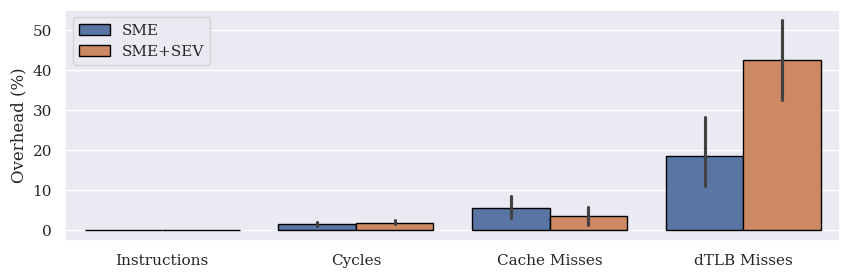

In [119]:
plot_df = overhead_df.melt(
    id_vars=["Mode"],
    value_vars=["Perf_Instructions_pct", "Perf_Cycles_pct", "Perf_CacheMisses_pct", "Perf_dTLBMisses_pct"],
    var_name="Metric",
    value_name="Overhead_pct"
)

plot_df["Metric"] = plot_df["Metric"].map({
    "Perf_Instructions_pct": "Instructions",
    "Perf_Cycles_pct": "Cycles",
    "Perf_CacheMisses_pct": "Cache Misses",
    "Perf_dTLBMisses_pct": "dTLB Misses",
})

plt.figure(figsize=(10, 3))
sns.barplot(data=plot_df, x="Metric", y="Overhead_pct", errorbar=('ci', 95), edgecolor='black', hue="Mode")
plt.legend(title=None)
plt.xlabel("")
plt.ylabel("Overhead (%)")
plt.savefig("images/overhead_by_perf_metric.pdf", bbox_inches='tight')

summary = (plot_df.groupby(['Metric', 'Mode'])['Overhead_pct']
           .mean()
           .round(2)
           .unstack())

print(summary.to_string(float_format="{:.1f}".format))
print("\n" + "-" * 60)

Mode            Native         SME     SME+SEV
Randomness                                    
0.0          164464902   166320713   165070056
1.0        47727044430 47568715910 47659196643
Mode        SME  SME+SEV
Randomness              
0.0        10.9      6.5
1.0         0.3      0.5


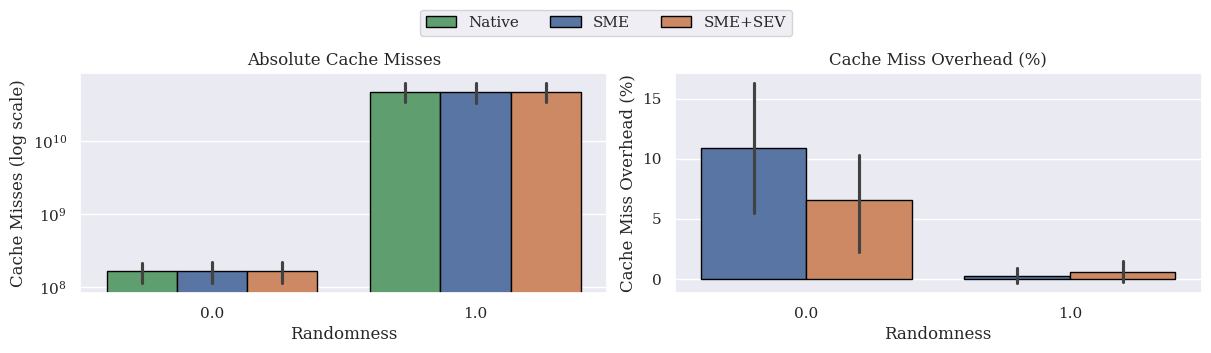

In [120]:
base = sns.color_palette("deep", 3)
palette = {
    "Native": base[2],  
    "SME": base[0],     
    "SME+SEV": base[1] 
}

fig, ax = plt.subplots(ncols=2, figsize=(12, 3), constrained_layout=True)

sns.barplot(data=df, x="Randomness", y="Perf_CacheMisses", hue="Mode", palette=palette, errorbar=('ci', 95), edgecolor='black', ax=ax[0])
ax[0].set_yscale("log")
ax[0].set_title("Absolute Cache Misses")
ax[0].set_ylabel("Cache Misses (log scale)")
ax[0].get_legend().remove()


sns.barplot(data=overhead_df, x="Randomness", y="Perf_CacheMisses_pct", hue="Mode", palette=palette, errorbar=('ci', 95), edgecolor='black', ax=ax[1])
ax[1].set_title("Cache Miss Overhead (%)")
ax[1].set_ylabel("Cache Miss Overhead (%)")
ax[1].get_legend().remove()

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)

plt.savefig("images/cache_misses_absolute_and_overhead_by_randomness.pdf", bbox_inches='tight')

print(df.groupby(['Randomness', 'Mode'])['Perf_CacheMisses'].mean().unstack().to_string(float_format="{:.0f}".format))
print(overhead_df.groupby(['Randomness', 'Mode'])['Perf_CacheMisses_pct'].mean().unstack().to_string(float_format="{:.1f}".format))

# IO Analysis

Mode     MB    
SME      10.0       3.770408
         70.0       6.145966
         150.0      6.696628
         500.0      6.796668
         3000.0     8.537110
SME+SEV  10.0       5.535322
         70.0      11.822315
         150.0      9.990332
         500.0      9.022988
         3000.0     9.868259
Name: IO_Time_pct, dtype: float64


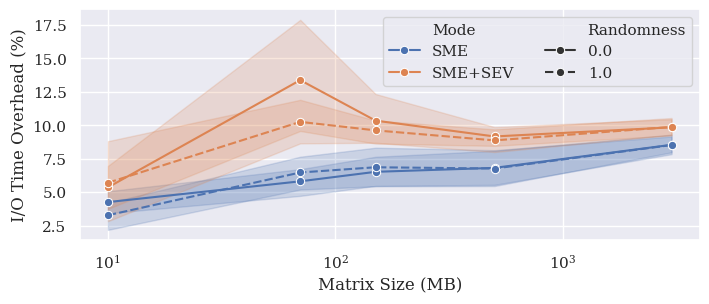

In [121]:
#Randomness does not have a significant impact on I/O time overhead
plt.figure(figsize=(8, 3))
sns.lineplot(data=overhead_df, x="MB", y="IO_Time_pct", marker="o", hue="Mode", style="Randomness")
plt.xscale("log")
plt.xlabel("Matrix Size (MB)")
plt.ylabel("I/O Time Overhead (%)")
plt.legend(ncol=2)
plt.savefig("images/IO_Time_Overhead_by_MB.pdf", bbox_inches='tight')
print(overhead_df.groupby(["Mode", "MB"])["IO_Time_pct"].mean())